# Recurrent Neural Networks

Author: Ethan Robert A. Casin

Note: RNN and LSTM content was derived from the CNN lecture of Christopher Monterola, PhD

---

## Introduction

For this lecture, we will be discussing a very important model in deep learning. From our previous time series lecture, we saw that the treatment for time series data is very different from our typical tabular dataset. The main reason is its temporal dependencies. 

To connect to our lecture today from what we've learned, we'll try to revist time series data. Note that the models that we're discussing here can be applied to any sequential dataset, especially text data. 

To begin, let's import all of our materials first.

In [1]:
from typing import Union, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchvision.transforms import ToTensor

plt.rcParams["figure.figsize"] = (15, 5)

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

torch.manual_seed(42)


Using mps device


## Revisiting Sequential Data

---

**Question**: What is sequential data and what sets it apart from other types of data?

---



To make our course more cohesive, let's use the same functions we've defined in the past and we'll also use our `sunspots` data from `statsmodels`.

In [3]:
def train_test_split(data: pd.Series, lookback: int = 12, test_size: int = 12) -> Tuple[pd.Series, pd.Series]:
    """Create a train-test split on your pd.Series data.

    Parameters:
    -----------
    data (pd.Series): The univariate time series provided
    lookback (int): The lookback periods to consider
    test_size (int): The length of the test set

    Returns:
    --------
    Tuple (pd.Series): The (train, test) pandas series generated
    """
    
    split = data.shape[0] - test_size
    return (
        data.iloc[:split],
        data.iloc[split - lookback: ]
    )

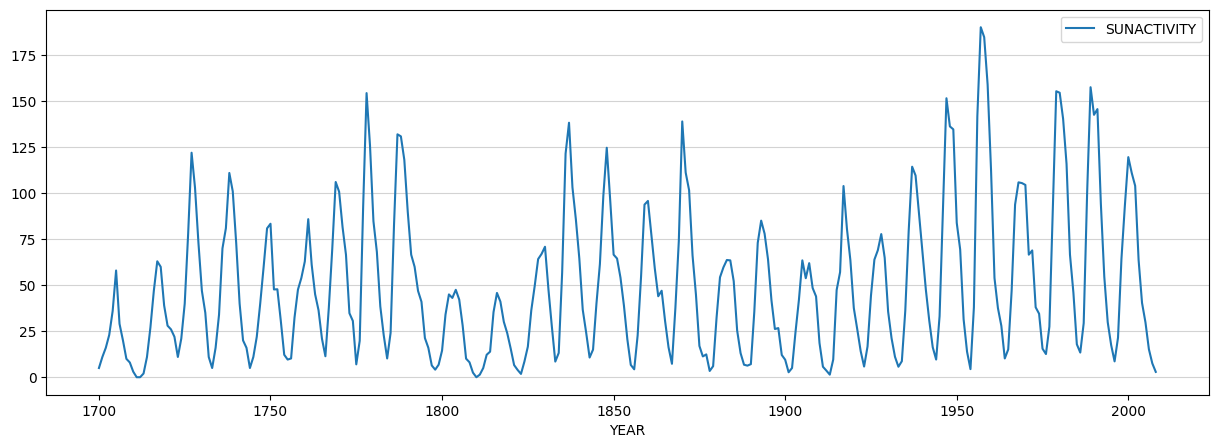

In [4]:
df = sm.datasets.sunspots.load_pandas().data
df["YEAR"] = df["YEAR"].astype(int)

df.set_index("YEAR", inplace=True)

df.plot()
plt.grid(axis="y", c="lightgray")
plt.show()

We'll use the same lookback window and we'll be forecasting ony $h=1$ year ahead. This time though, we will be defining our validation set.

Training instances: (222,)
Validation instances: (35,)
Test instances: (72,)


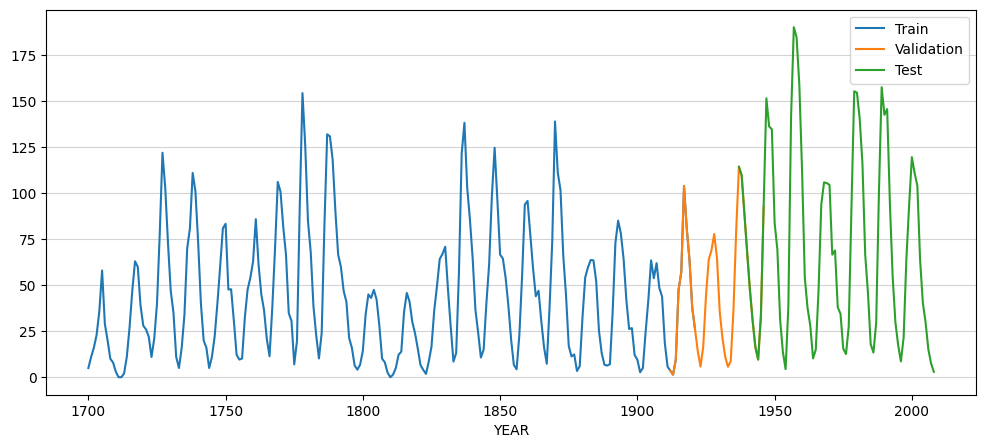

In [5]:
lookback = 10 # lookback in years

test_prop = 0.2 # we get the last 20% from our data
val_prop = 0.1 # we get the last 10% from our train set

n_points = df.shape[0]
test_size = round(n_points * test_prop)

horizon = 1 # forecasting 1 year ahead

Train, test = train_test_split(df["SUNACTIVITY"], lookback=lookback, test_size=test_size)

# Creation of the validation set
val_size = round(Train.shape[0] * val_prop)
train, val = train_test_split(Train, lookback=lookback, test_size=val_size)


print(f"Training instances: {train.shape}")
print(f"Validation instances: {val.shape}")
print(f"Test instances: {test.shape}")
## Plot

fig, ax = plt.subplots(figsize=(12,5))

train.plot(ax=ax)
val.plot(ax=ax)
test.plot(ax=ax)

plt.legend(["Train", "Validation", "Test"])
plt.grid(axis="y", c="lightgray")
plt.show()

Now there's one quirk that neural networks and many other deep learning algorithms share. 

---

**Question**: Why do we need to always scale our data for deep learning?

---

For the remainder of this lecture, we will be normalizing our dataset using the z-score (this is equivalent to doing `StandardScaler` in `scikit-learn`) from our training set.

---

**Question**: Why the training set?

---

In [6]:
# We'll use this to rescale our predictions later
mu = train.mean()
sigma = train.std()

train = (train - mu) / sigma
val = (val - mu) / sigma
test = (test - mu) / sigma

We then create our corresponding `X` and `y` arrays.

In [7]:
def create_xy(series: pd.Series, lookback: int = 12, horizon: int = 1) -> Tuple[np.ndarray, np.ndarray]:
    """Create the X and y arrays from a pd.Series object. The `lookback`
    determines the number of features we would include in X. While the
    `horizon` paramter informs us how many points we'll need to forecast.

    Paramters:
    ----------
    series (pd.Series): the (n, 1) time series to be sliced into X and Y
    lookback (int): the lookback window to consider (default=12)
    horizon (int): the number of points to forecast for each row in X (default=1)

    Returns:
    -------
    (X, y) (Tuple): a tuple of ndarrays
    """
    x = []
    y = []
    
    series_size = series.shape[0]
    for i in range(series_size):
        # break loop if series is less than the required time horizon
        if series.iloc[(i + lookback): (i + lookback + horizon)].shape[0] < horizon:
            break
        x.append(
            series.iloc[i: (i + lookback)]
        )
        y.append(
            series.iloc[(i + lookback): (i + lookback + horizon)]
        )
    x = np.dstack(x)
    y = np.dstack(y)

    # Reshape x to (samples, features, lookback)
    x = np.swapaxes(x, 0, 2)
    # Then flatten (samples, features * lookback)
    x = x.reshape(x.shape[0], x.shape[1] * x.shape[2])

    # Reshape y tp (samples, horizon)
    y = np.swapaxes(y, 0, 2)
    y = y[:, :, 0]


    
    return x, y

We can print out our data shapes to check how many points we'll be dealing with. 

In [8]:
horizon = 1

train_X, train_y = create_xy(train, lookback=lookback, horizon=horizon)
val_X, val_y = create_xy(val, lookback=lookback, horizon=horizon)
test_X, test_y = create_xy(test, lookback=lookback, horizon=horizon)

print("X-Y Shapes")
print("=" * 20)
print(f"Train X: {train_X.shape}")
print(f"Train Y: {train_y.shape}")
print(f"Val X: {val_X.shape}")
print(f"Val Y: {val_y.shape}")
print(f"Test X: {test_X.shape}")
print(f"Test Y: {test_y.shape}")

X-Y Shapes
Train X: (212, 10)
Train Y: (212, 1)
Val X: (25, 10)
Val Y: (25, 1)
Test X: (62, 10)
Test Y: (62, 1)


### MLP on Sequential Data

In our time series lecture, we saw that we can try to force any classical machine learning model to be "temporally-aware" by using autoregressors. 

If that's the case, well why not use a standard multi-layer perceptron (MLP) for time series forecasting? Why bother creating a new algorithm for it? Let's check it out.

Let's create a simple neural network called `SimpleMLP`. This is just the same model we had from our previous `backpropagation` lecture.

In [9]:
class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        n_hidden_layers,
        n_hidden_nodes,
        n_output_nodes,
        dropout_rate=0.2,
    ):
        super().__init__()

        layers = [nn.Linear(input_dim, n_hidden_nodes), nn.ReLU(), nn.Dropout(dropout_rate)]
        for h in range(n_hidden_layers):
            layers.extend(
                [nn.Linear(n_hidden_nodes, n_hidden_nodes), nn.ReLU(), nn.Dropout(dropout_rate)]
            )
        layers.extend([nn.Linear(n_hidden_nodes, n_output_nodes), nn.ReLU()])
        self.network = nn.Sequential(*layers)

    def forward(self, X):
        return self.network(X)

We also define our `train_model` function. 

**Note: You can actually define this function within the model class itself. We used a separate function for our lectures for convenience and to get used to certain implementations out there.** 

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=100, show_grad=False):
    
    train_losses = []
    val_losses = []
    
    n_trainloader = len(train_loader)
    n_valloader = len(val_loader)
    
    # Model training
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for X_batch, y_batch in train_loader:
            # Define where to put the data
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
                
            # Print gradients
            if show_grad:
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        print(f"{name}: grad_norm = {param.grad.norm().item():.6f}")
            optimizer.step()
            running_loss += loss.item()
    
        train_losses.append(running_loss / n_trainloader)
    
        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for X_val, y_val in val_loader:
                # Define where to put the data

                X_val = X_val.to(device)
                y_val = y_val.to(device)
                
                preds = model(X_val)
                # no need to do backpropagation for inference
                vloss = criterion(preds, y_val)
                val_loss += vloss.item()
            val_losses.append(val_loss / n_valloader)
    return train_losses, val_losses

We define an arbitrary batch size of 20 and do the standard things we've done to create a PyTorch dataset.

In [11]:
batch_size = 20
dtype = torch.float32 # float32 is required by PyTorch

training_tensor = TensorDataset(
    torch.tensor(train_X, dtype=dtype), torch.tensor(train_y, dtype=dtype)
)
validation_tensor = TensorDataset(
    torch.tensor(val_X, dtype=dtype), torch.tensor(val_y, dtype=dtype)
)
test_tensor = TensorDataset(
    torch.tensor(test_X, dtype=dtype), torch.tensor(test_y, dtype=dtype)
)

train_loader = DataLoader(training_tensor, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(validation_tensor, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size=batch_size, shuffle=False)

We can now do our model training.

In [12]:
lr = 0.0001

model = SimpleMLP(
    input_dim=lookback,
    n_hidden_layers=4,
    n_hidden_nodes=100,
    n_output_nodes=horizon,
    dropout_rate=0.2,
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr) # make sure you pass the correct model

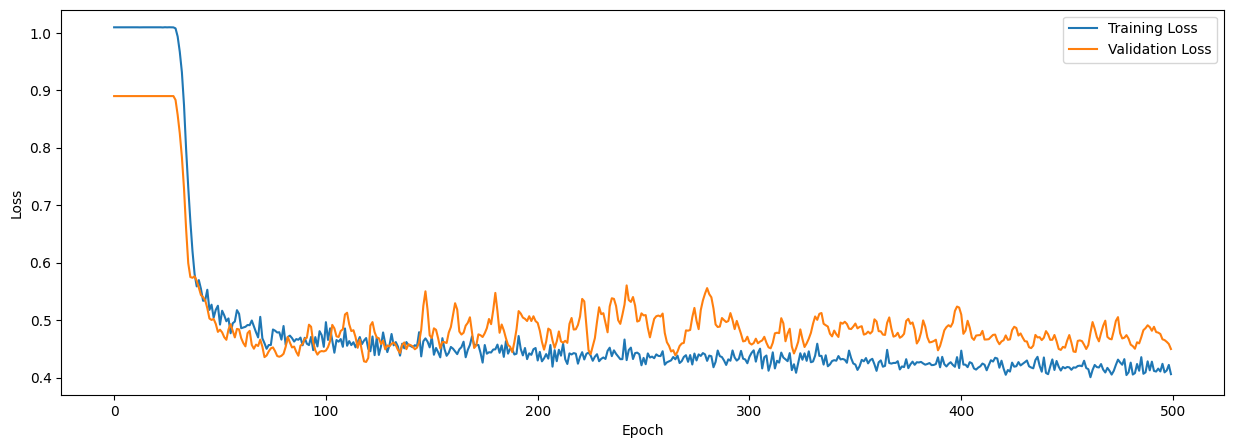

In [13]:
train_loss, val_loss = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=500,
)

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

---

**Question**: What can you say about the graph above?

---

Now that we have our trained model, let's now make inferences with it using a `forward` pass.

MSE: 727.8414969905529
R2: 0.7387989196281786


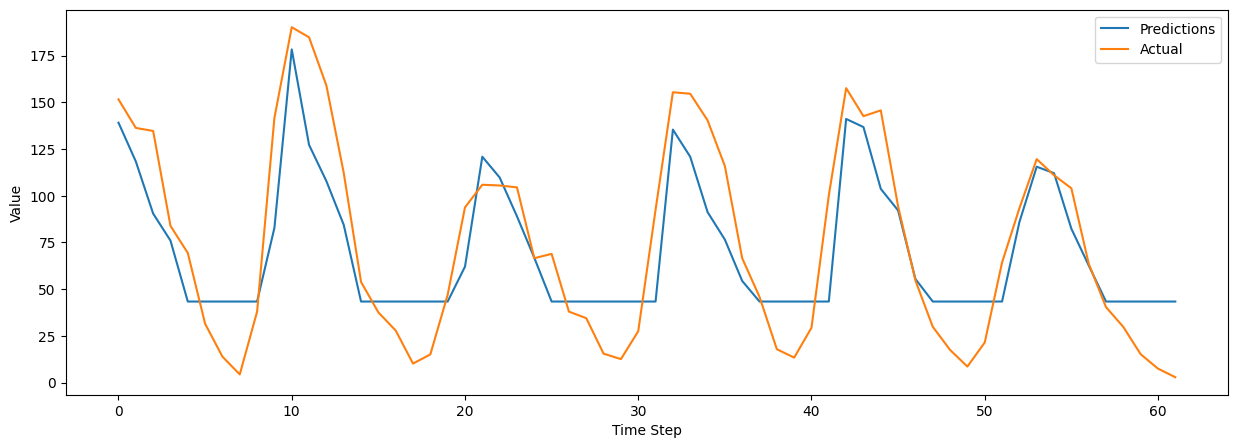

In [14]:
model.eval()
preds = model(torch.tensor(test_X, dtype=dtype).to(device)).cpu().detach()

#rescaling
preds = preds * sigma + mu
test_y_rescaled = test_y * sigma + mu

print(f"MSE: {mean_squared_error(test_y_rescaled, preds)}")
print(f"R2: {r2_score(test_y_rescaled, preds)}")

plt.plot(preds, label="Predictions")
plt.plot(test_y_rescaled, label="Actual")

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()

---

**Question** What can you say about the MLP?

---

## RNNs and Sequential Data

As you may have guessed by now, MLPs and CNNs were not designed to handle the order of input samples. One can say that such models do not have a "memory" of the past seen samples. 

For example, the samples are passed through the feedforward and backpropagation steps, and the weights get updated independent of the order in which the sample is processed. 

Recurrent neural networks (RNNs) are designed for modeling sequences and are capable of remembering past information and process new events appropriately.

### Different categories of sequence modeling

Sequence modeling has a ton of applications. From time series forecasting, langauge translation, image captioning, and text generation (e.g., ChatGPT). In order to understand the appropriate model to use, we need to understand the different types of sequential modeling tasks. 

The figure below from the article *[The Unreasonable Effectiveness of Recurrent Neural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)* by Andrej Karpathy, shows several different relationship categories of input and output data.

<img width="716" alt="RNN_categories" src="https://user-images.githubusercontent.com/25600601/142829866-6c30b056-42a0-4409-806c-0ec355f0f310.png">

If either the input or output data is a sequence, the data will form one of the following three categories:

1. **Many-to-one**: The input data is a sequence, but the output is a fixed-size vector, not a sequence. For example, in sentiment analysis, the input is textbased and the output is a class label.
2. **One-to-many:** The input data is in standard format, not a sequence, but the output is a sequence. An example of this category is image captioning—the input is an image; the output is an English phrase.
3. **Many-to-many:** Both the input and output arrays are sequences. This category can be further divided based on whether the input and output are synchronized or not. An example of a synchronized many-to-many modeling task is video classification, where each frame in a video is labeled. An example of a delayed many-to-many would be translating a language into another. For instance, an entire English sentence must be read and processed by a machine before producing its translation into Filipino.

### Understanding RNNs

The architecture of an RNN is not drastically different from a standard MLP. The figure below provides a side-by-side comparison of a standard MLP and an RNN.

<img width="869" alt="RNNvsfeedforwardNN" src="https://user-images.githubusercontent.com/25600601/142830255-11b5251c-091e-4487-beb0-68dfc904e75a.png">

Both of these networks have only one hidden layer. In this representation, the units are not displayed, but we assume that the input layer ($\mathbf{x}$), hidden layer ($\mathbf{h}$), and output layer ($\mathbf{y}$) are vectors which contain many units.

In a standard feedforward network, information flows from the input to the hidden layer, and then from the hidden layer to the output layer. On the other hand, in a recurrent network, the hidden layer gets its input from both the input layer and the hidden layer from the previous time step.

The flow of information in adjacent time steps in the hidden layer allows the network to have a memory of past events. This flow of information is usually displayed as a loop, also known as a recurrent edge in graph notation, which is how this general architecture got its name.

In the following figure, the single hidden layer network and the multilayer network illustrate two contrasting architectures:

<img width="718" alt="RNN_architectures" src="https://user-images.githubusercontent.com/25600601/142830328-445ed659-b79e-4231-b4cc-7653ccb5b406.png">

In order to examine the architecture of RNNs and the flow of information, a compact representation with a recurrent edge can be unfolded, which you can see in the preceding figure. As we know, each hidden unit in a standard neural network receives only one input—the net preactivation associated with the input layer. Now, in contrast, each hidden unit in an RNN receives two distinct sets of input—the preactivation from the input layer and the activation of the same hidden layer from the previous time step t-1.

At the first time step t = 0, the hidden units are initialized to zeros or small random values. Then, at a time step where t > 0, the hidden units get their input from the data point at the current time $\mathbf{x}^{(t)}$ and the previous values of hidden units at t - 1, indicated as $\mathbf{h}^{(t-1)}$.

Similarly, in the case of a multilayer RNN, we can summarize the information flow as follows:

• *layer =1*: Here, the hidden layer is represented as $\mathbf{h_1}^{(t)}$ and gets its input
from the data point $\mathbf{x}^{(t)}$ and the hidden values in the same layer, but the previous time step $\mathbf{h_1}^{(t-1)}$

• *layer = 2* : The second hidden layer, $\mathbf{h_2}^{(t)}$ receives its inputs from the hidden units from the layer below at the current time step $\mathbf{h_1}^{(t)}$ and its own hidden values from the previous time step $\mathbf{h_2}^{(t-1)}$

### Computing activations in an RNN

Now that we understand the structure and general flow of information in an RNN, let's get more specific and compute the actual activations of the hidden layers as well as the output layer. For simplicity, we'll consider just a single hidden layer; however, the same concept applies to multilayer RNNs.

Each directed edge (the connections between boxes) in the representation of an RNN that we just looked at is associated with a weight matrix. Those weights do not depend on time t; therefore, they are shared across the time axis. The different weight matrices in a single layer RNN are as follows:

• $\mathbf{W}_{xh}$ : The weight matrix between the input $\mathbf{x}^{(t)}$ and the hidden layer $\mathbf{h}$   
• $\mathbf{W}_{hh}$ : The weight matrix associated with the recurrent edge   
• $\mathbf{W}_{hy}$: The weight matrix between the hidden layer and output layer   

You can see these weight matrices in the following figure:

<img width="877" alt="RNN_weightmatrices" src="https://user-images.githubusercontent.com/25600601/142830555-fe261213-9fcd-416d-a0c7-cfc12af74f86.png">

In certain implementations, you may observe that weight matrices $\mathbf{W}_{xh}$ and $\mathbf{W}_{hh}$ are concatenated to a combined matrix $\mathbf{W}_{h}$ = [$\mathbf{W}_{xh}$; $\mathbf{W}_{hh}$]. Later on, we'll make use of this notation as well.


Computing the activations is very similar to standard multilayer perceptrons and other types of feedforward neural networks. For the hidden layer, the net input $\mathbf{z}_h$(preactivation) is computed through a linear combination. That is, we compute the sum of the multiplications of the weight matrices with the corresponding vectors and add the bias unit --- $\mathbf{z}_h$=$\mathbf{W}_{xh}\mathbf{x}^{(t)} + \mathbf{W}_{hh} \mathbf{h}^{(t-1)} + \mathbf{b}_h$. Then, the activations of the hidden units at the time step t are calculated as follows:

\begin{equation}
\mathbf{h}^{(t)}= \phi_h(\mathbf{z}_h) = \phi_h(\mathbf{W}_{xh} \mathbf{x}^{(t)} + \mathbf{W}_{hh} \mathbf{h}^{(t-1)} + \mathbf{b}_{h})
\end{equation}

Here, $\mathbf{b}_{h}$ is the bias vector for the hidden units and $\phi_h( )$  is the activation function
of the hidden layer.



In case you want to use the concatenated weight matrix $\mathbf{W}_{h}$ = [$\mathbf{W}_{xh}$; $\mathbf{W}_{hh}$], the formula for computing hidden units will change as follows:

\begin{equation}
\mathbf{h}^{(t)}= \phi_h(\mathbf{W}_{h}\begin{bmatrix}\mathbf{x}^{(t)}\\
\mathbf{h}^{(t-1)} \\
\end{bmatrix} + \mathbf{b}_{h})
\end{equation}


Once the activations of hidden units at the current time step are computed, then the activations of output units will be computed as follows:

\begin{equation}
\mathbf{y}^{(t)}= \phi_y(\mathbf{W}_{hy}\mathbf{h}^{(t)} + \mathbf{b}_{y})
\end{equation}

To help clarify this further, the following figure shows the process of computing
these activations with both formulations:

<img width="869" alt="RNNvsfeedforwardNN" src="https://user-images.githubusercontent.com/25600601/142830623-5affd7c0-6240-4f0f-b829-f3446eb3a751.png">


Backpropagation now proceeds as usual as we have not a clear expresssion for weights and output of the RNN.


Let's first see how to develop an RNN. Now there is a shape requirement that we must adhere to for RNNs. Currently, our datasets follow the shape `(n_observations, lookback)`. However, RNNs and other deep learning models require us to adhere to tensor definition of matrices. Because we're dealing with a univariate time series, we need to reshape our matrices into `(n_observations, lookback, 1)`.

In [15]:
train_X_rnn = train_X.reshape(train_X.shape[0], lookback, 1)
val_X_rnn   = val_X.reshape(val_X.shape[0], lookback, 1)
test_X_rnn  = test_X.reshape(test_X.shape[0], lookback, 1)

training_tensor_rnn = TensorDataset(
    torch.tensor(train_X_rnn, dtype=dtype), torch.tensor(train_y, dtype=dtype)
)
validation_tensor_rnn = TensorDataset(
    torch.tensor(val_X_rnn, dtype=dtype), torch.tensor(val_y, dtype=dtype)
)
test_tensor_rnn = TensorDataset(
    torch.tensor(test_X_rnn, dtype=dtype), torch.tensor(test_y, dtype=dtype)
)

train_loader_rnn = DataLoader(training_tensor_rnn, batch_size=batch_size, shuffle=False)
val_loader_rnn = DataLoader(validation_tensor_rnn, batch_size=batch_size, shuffle=False)
test_loader_rnn = DataLoader(test_tensor_rnn, batch_size=batch_size, shuffle=False)

We then build out our RNN from scratch. If you'll notice, there's not a lot of differences, except for the `forward` method.

---

**Question**: Who can explain what's going on with `h_t`?

---

In [16]:
class SimpleRNN(nn.Module):
    def __init__(self, input_dim, n_hidden_nodes, n_output_nodes):
        super().__init__()
        self.input_size = input_dim
        self.hidden_size = n_hidden_nodes

        # recall that z_h = W_xh x(t) + W_hh h(t-1) + b_h
        self.W_xh = nn.Linear(input_dim, n_hidden_nodes, bias=False)
        self.W_hh = nn.Linear(n_hidden_nodes, n_hidden_nodes) # b_y is here

        self.W_hy = nn.Linear(n_hidden_nodes, n_output_nodes)

    def forward(self, X):
        batch_size, seq_len, lookback = X.size()
        h_t = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for t in range(seq_len):
            x_t = X[:, t, :] # Get timestep t from the input
            h_t = torch.tanh(self.W_xh(x_t) + self.W_hh(h_t)) # You can use relu if you want
        return torch.relu(self.W_hy(h_t))

We'll then use the same parameters as our MLP and review the results.

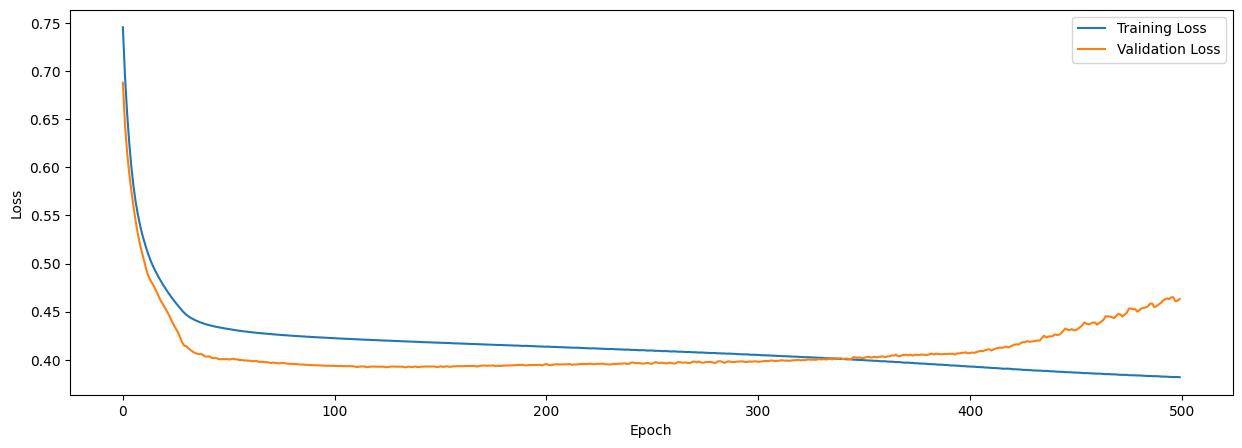

In [17]:
simpleRNN = SimpleRNN(1, 100, horizon).to(device)

lr = 0.0001
optimizer = optim.Adam(simpleRNN.parameters(), lr=lr)

train_loss, val_loss = train_model(
    simpleRNN,
    train_loader_rnn,
    val_loader_rnn,
    criterion,
    optimizer,
    device,
    epochs=500,
)

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

MSE: 680.5865060188704
R2: 0.7557573573454559


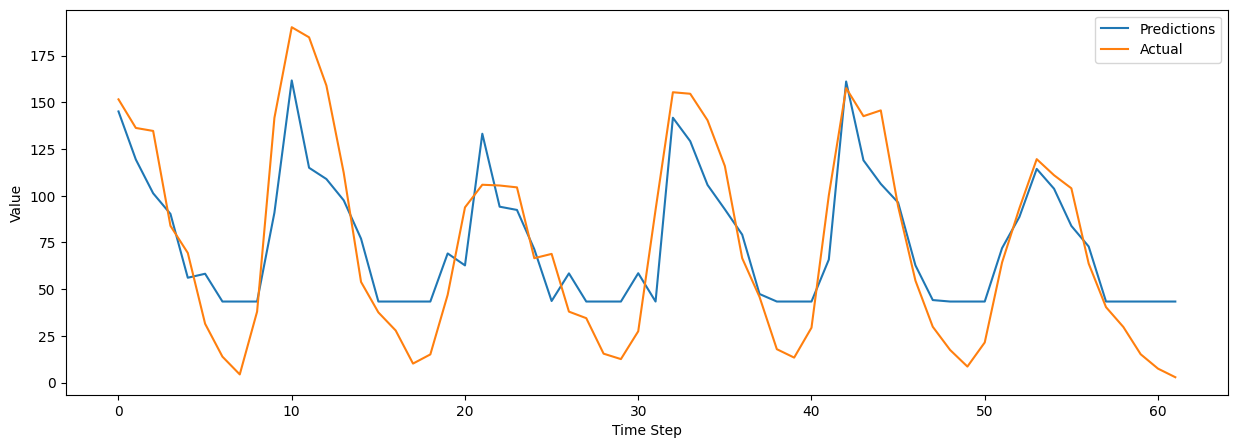

In [18]:
simpleRNN.eval()
preds = simpleRNN(torch.tensor(test_X_rnn, dtype=dtype).to(device)).cpu().detach()

preds = preds * sigma + mu
test_y_rescaled = test_y * sigma + mu

print(f"MSE: {mean_squared_error(test_y_rescaled, preds)}")
print(f"R2: {r2_score(test_y_rescaled, preds)}")

plt.plot(preds, label="Predictions")
plt.plot(test_y_rescaled, label="Actual")

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()

---

**Question:** What can you observe with the outputs?

---

Of course, the typical way of creating an RNN is not from scratch. PyTorch already has the `nn.RNN` class that we can use. Below is a typical way of creating an RNN. We will be using this syntax moving forward.

In [19]:
class TypicalRNN(nn.Module):
    def __init__(self, input_dim, n_hidden_nodes, n_output_nodes, num_layers):
        super().__init__()
        self.hidden_size = n_hidden_nodes
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=n_hidden_nodes,
            num_layers=num_layers,
            batch_first=True,  # means that X has shape (batch_size, seq_len, input_dim)
            nonlinearity="relu",

        )
        self.mlp = nn.Linear(n_hidden_nodes, n_output_nodes)


    def forward(self, X):
        batch_size = X.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=X.device)
        rnn_out, h_n = self.rnn(X, h0)

        # Take the last hidden state
        last_step = h_n[-1]
        return self.mlp(last_step)


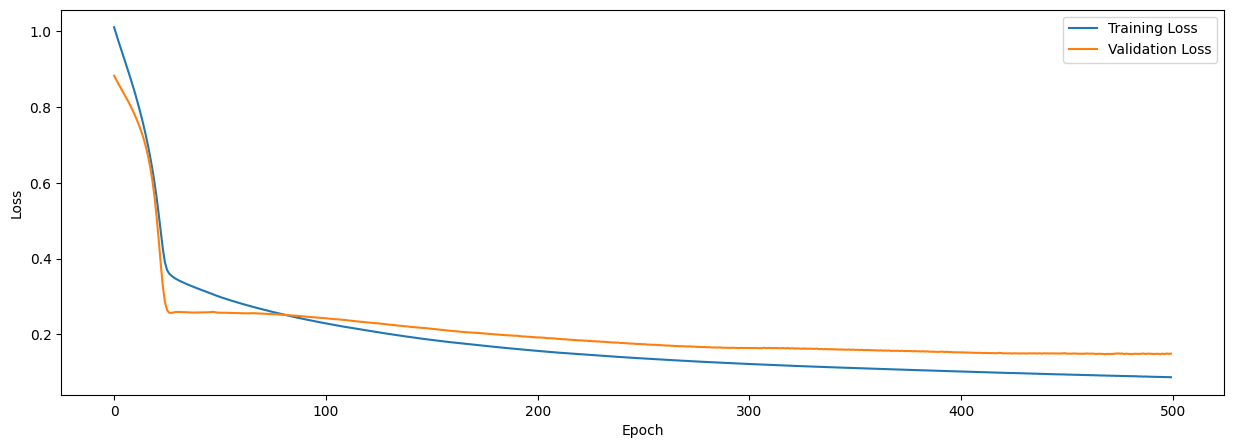

In [20]:
typicalRNN = TypicalRNN(1, 100, horizon, 1).to(device)

lr = 0.0001
optimizer = optim.Adam(typicalRNN.parameters(), lr=lr)


train_loss, val_loss = train_model(
    typicalRNN,
    train_loader_rnn,
    val_loader_rnn,
    criterion,
    optimizer,
    device,
    epochs=500,
)

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

MSE: 416.51125419813553
R2: 0.8505262615096711


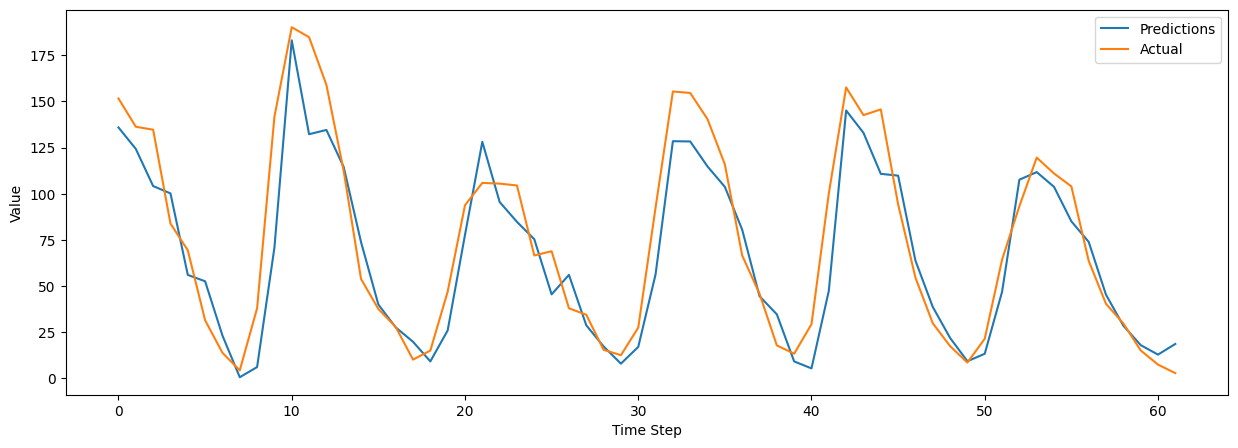

In [21]:
typicalRNN.eval()
preds = typicalRNN(torch.tensor(test_X_rnn, dtype=dtype).to(device)).cpu().detach().squeeze()

preds = preds * sigma + mu
test_y_rescaled = test_y * sigma + mu

print(f"MSE: {mean_squared_error(test_y_rescaled, preds)}")
print(f"R2: {r2_score(test_y_rescaled, preds)}")

plt.plot(preds, label="Predictions")
plt.plot(test_y_rescaled, label="Actual")

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()

### Exploding and Vanishing Kittens

<img width="709" alt="RNN_BPTT" src="https://user-images.githubusercontent.com/25600601/142831664-4882c954-55b5-45f6-9bc1-da05889f2363.png">

Backpropagation through time, or BPTT, which we briefly mentioned in the previous
information box, introduces some new challenges. Because of the multiplicative factor $\frac{\partial \mathbf{h}^{(t)}}{\partial \mathbf{h}^{(k)}}$ in the computing gradients of a loss function, the so-called vanishing or exploding gradient problem arises. This problem is explained through the examples in the following figure, which shows an RNN with only one hidden unit for simplicity:

<img width="869" alt="RNN_gradients" src="https://user-images.githubusercontent.com/25600601/142831742-9324ea36-9a4c-46e4-ab18-a30ba49b0e0e.png">

Basically, $\frac{\partial \mathbf{h}^{(t)}}{\partial \mathbf{h}^{(k)}}$ has t − k multiplications; therefore, multiplying the $w$ weight t − k times results in a factor — $w^{t−k}$. As a result, if $w$ <1, this factor becomes very small when t − k is large. On the other hand, if the weight of the recurrent edge is w >1,
then $w^{t−k}$ becomes very large when t − k is large. Note that large t − k refers to longrange dependencies.

Intuitively, we can see that a naive solution to avoid vanishing or exploding gradient can be accomplished by ensuring $|w|=1$. If you are interested and would like to investigate this in more detail, I encourage you to read *On the difficulty of training recurrent neural networks by R. Pascanu, T. Mikolov, and Y. Bengio, 2012 (https://
arxiv.org/pdf/1211.5063.pdf).*

In practice, there are two solutions to this problem:

• Truncated backpropagation through time (TBPTT)  
• Long short-term memory (LSTM)  

TBPTT clips the gradients above a given threshold. While TBPTT can solve the exploding gradient problem, the truncation limits the number of steps that the gradient can effectively flow back and properly update the weights.

On the other hand, LSTM, designed in 1997 by Hochreiter and Schmidhuber, has been more successful in modeling long-range sequences by overcoming the vanishing gradient problem. Let's discuss LSTM in more detail in the next section.

Number of parameters: num_units* num_units + num_features* num_units + biases

## LSTM

Long short-term memory (LSTM) was first introduced to overcome the vanishing gradient problem. The main building block of an LSTM is a memory cell, which essentially represents the hidden layer.

In each memory cell, there is a recurrent edge that has the desirable weight w =1, as we discussed previously, to overcome the vanishing and exploding gradient problems. The values associated with this recurrent edge is called cell state. The unfolded structure of a modern LSTM cell is shown in the following figure:

<img width="1021" alt="RNN_LSTM" src="https://user-images.githubusercontent.com/25600601/142831002-2544020d-36e3-4976-b0d1-7fc8fc4f0cdb.png">

Notice that the cell state from the previous time step, $\mathbf{C}^{(t−1)}$, is modified to get the cell
state at the current time step,  $\mathbf{C}^{(t)}$ , without being multiplied directly with any weight
factor. For comparison, here is how the simple RNN is changed by LSTM:

<img width="701" alt="RNN_LSTM2" src="https://user-images.githubusercontent.com/25600601/142831098-289119a4-8331-4cde-a823-5493354ccd1d.png">


The flow of information in this memory cell is controlled by some units of computation that we'll describe here. In the previous figure, $\odot$ refers to the element-wise product (element-wise multiplication) and means $\oplus$ element-wise summation (element-wise addition). Furthermore, $\mathbf{x}^{(t)}$ refers to the input data at time t, and $\mathbf{h}^{(t−1)}$ indicates the hidden units at time t −1.


Four boxes are indicated with an activation function, either the sigmoid function ($\sigma$) or hyperbolic tangent ($\tanh$), and a set of weights; these boxes apply linear combination by performing matrix-vector multiplications on their input. These units of computation with sigmoid activation functions, whose output units are passed through $\odot$, are called **gates**.

In an LSTM cell, there are three different types of gates, known as the forget gate, the
input gate, and the output gate:

• The **forget gate** ($\mathbf{f}_t$) allows the memory cell to reset the cell state without growing indefinitely. In fact, the forget gate decides which information is allowed to go through and which information to suppress. Now, $\mathbf{f}_t$ is computed as follows:

\begin{equation}
\mathbf{f}_{t}= \sigma(\mathbf{W}_{xf}\mathbf{x}^{(t)} + \mathbf{W}_{hf}\mathbf{h}^{(t-1)} + \mathbf{b}_{f})
\end{equation}

Note that the forget gate was not part of the original LSTM cell; it was added a few years later to improve the original model (*Learning to Forget: Continual Prediction with LSTM, F. Gers, J. Schmidhuber, and F. Cummins, Neural Computation 12, 2451-2471, 2000*).

• The **input gate** ($\mathbf{i}_t$) and **input node** ( $\mathbf{g}_t$ ) are responsible for updating the cell
state. They are computed as follows:

\begin{equation}
\mathbf{i}_{t}= \sigma(\mathbf{W}_{xi}\mathbf{x}^{(t)} + \mathbf{W}_{hi}\mathbf{h}^{(t-1)} + \mathbf{b}_{i})
\end{equation}

\begin{equation}
\mathbf{g}_{t}= \tanh(\mathbf{W}_{xg}\mathbf{x}^{(t)} + \mathbf{W}_{hg}\mathbf{h}^{(t-1)} + \mathbf{b}_{g})
\end{equation}

The cell state at time t is computed as follows:

\begin{equation}
\mathbf{C}^{t}= (\mathbf{C}^{t-1} \odot \mathbf{f}_{t}) \oplus (\mathbf{i}_{t} \odot \mathbf{g}_{t})
\end{equation}

The output gate ($\mathbf{o}_t$ ) decides how to update the values of hidden units:

\begin{equation}
\mathbf{o}_{t}= \sigma(\mathbf{W}_{xo}\mathbf{x}^{(t)} + \mathbf{W}_{ho}\mathbf{h}^{(t-1)} \mathbf{b}_{o})
\end{equation}


Given this, the hidden units at the current time step are computed as follows:

\begin{equation}
\mathbf{h}_{t}= \mathbf{o}_{t} \odot \tanh(\mathbf{C}^{t})
\end{equation}

The structure of an LSTM cell and its underlying computations might seem too complex. However, the good news is that TensorFlow has already implemented everything in wrapper functions that allows us to define our LSTM cells easily.


NOTE: The LSTM introduced here provides a basic approach for modeling long-range dependencies in sequences.
Yet, it is important to note that there are many variations of LSTMs described in literature (An Empirical Exploration of Recurrent Network Architectures, Rafal Jozefowicz, Wojciech Zaremba, and Ilya Sutskever,
Proceedings of ICML, 2342-2350, 2015). Also, worth noting is a more recent approach, called Gated Recurrent Unit (GRU), which was proposed in 2014. GRUs have a simpler architecture than LSTMs; therefore, they are computationally more efficient while their performance in some tasks, such as polyphonic music modeling, is comparable to LSTMs. If you are interested in learning more about these modern RNN architectures, refer to the paper, Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling by Junyoung Chung
and others 2014 (https://arxiv.org/pdf/1412.3555v1.pdf). Implementation of such can be an individual project.

Let's now try to implement our own LSTM model.

In [22]:
class TypicalLSTM(nn.Module):

    def __init__(self, input_dim, n_hidden_nodes, n_output_nodes, num_layers):
        super().__init__()

        self.hidden_size = n_hidden_nodes
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=n_hidden_nodes,
            num_layers=num_layers,
            batch_first=True,
        )
        self.mlp = nn.Linear(n_hidden_nodes, n_output_nodes)

    def forward(self, X):
        batch_size = X.size(0)
        
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=X.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=X.device)
        
        lstm_out, (h_n, c_n) = self.lstm(X, (h0, c0))

        # Take the last time step
        last_step = h_n[-1]

        return self.mlp(last_step)

If you can see, there's not a lot of differences between the LSTM implementation and our RNN implementation. In many online resources, you'll often encounter people creating an "RNN" but is actually using an LSTM or GRU under the hood. 

The main reason for that is that vanilla RNNs don't work well in practice and that "RNN" becomes more of an umbrella term for simplicity. 

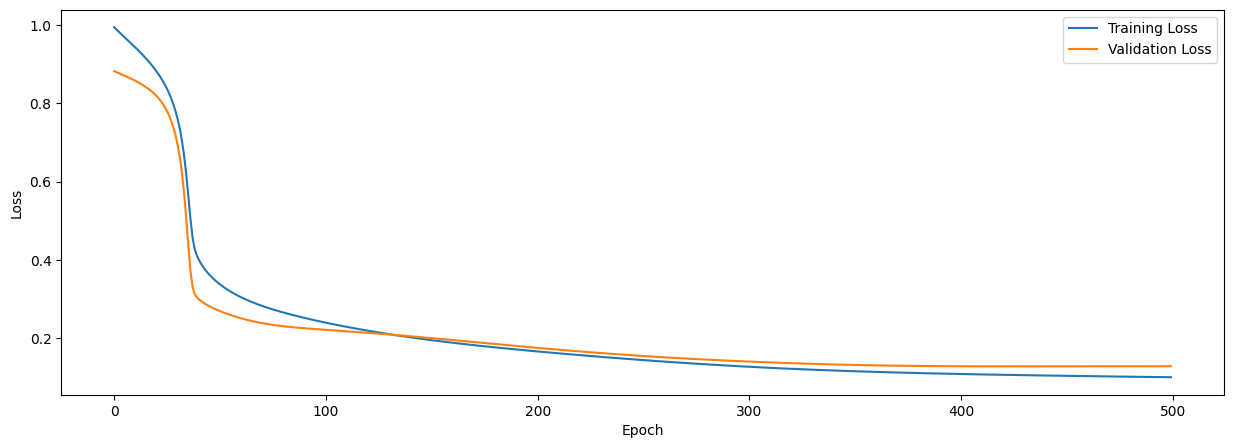

In [23]:
typicalLSTM = TypicalLSTM(1, 100, horizon, 1).to(device)

lr = 0.0001
optimizer = optim.Adam(typicalLSTM.parameters(), lr=lr)


train_loss, val_loss = train_model(
    typicalLSTM,
    train_loader_rnn,
    val_loader_rnn,
    criterion,
    optimizer,
    device,
    epochs=500,
)

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

MSE: 423.5814385684968
R2: 0.8479889785935388


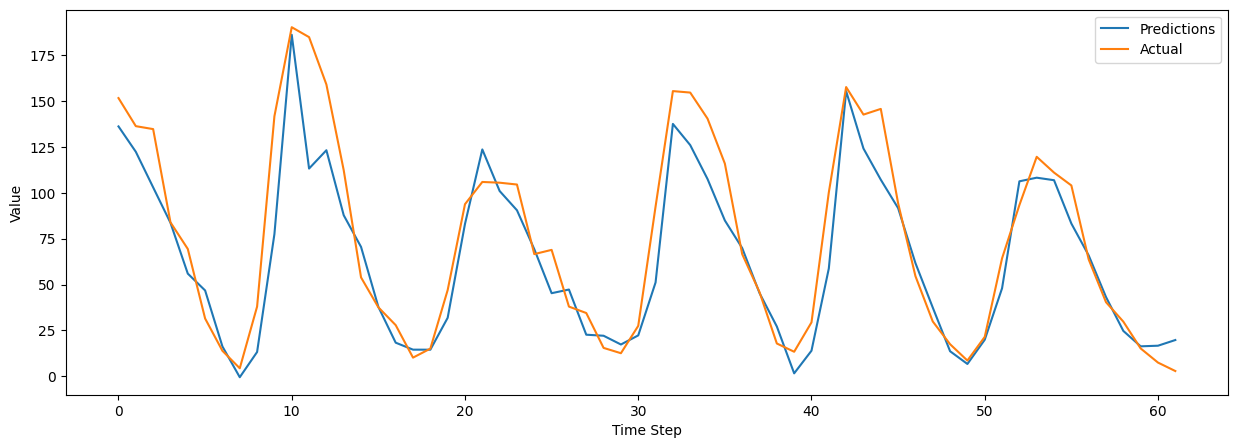

In [24]:
typicalLSTM.eval()
preds = typicalLSTM(torch.tensor(test_X_rnn, dtype=dtype).to(device)).cpu().detach().squeeze()

preds = preds * sigma + mu
test_y_rescaled = test_y * sigma + mu

print(f"MSE: {mean_squared_error(test_y_rescaled, preds)}")
print(f"R2: {r2_score(test_y_rescaled, preds)}")

plt.plot(preds, label="Predictions")
plt.plot(test_y_rescaled, label="Actual")

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()

---

**Question**: What can you notice from the outputs?

---

## An overview of self-attention

Although LSTMs can handle long-range dependencies, it still struggles to "forget" some data if it is far enough. You can image how crucial this is if you have, say, long form text inputs that span more than 1000 words. 

Another key limitation of an LSTM is that it's computationally expensive to run because of how it processes your data. Now what if we can do all of that, but faster?

One of the key innovations of the paper *Attention is All You Need* is the introduction of the self-attention mechanism. The general attention mechanism already exists prior to that. In 2015, a paper authored by Bahdanau, Cho, and Bengio (2015) titled "*Neural Machine Translation by Jointly Learning to Align and Translate*" introduced attention as a means of doing a "soft" search on text to improve translation tasks. Moreover, the introduced the RNN Encoder-Decoder framework, which became the building block of modern transformers.



Below is what we call the transformer. It looks complicated, but it does a lot of things right when it comes to sequential modeling. 


<img width="701" alt="RNN_LSTM2" src="https://aiml.com/wp-content/uploads/2023/09/Annotated-Transformers-Architecture.png">

Now discussing the overall architecture would require more than 1 session. What we can discuss today is just the main mechanism of the transformer and how we could use it for our lesson today. 

This mechanism is called the self-attention mechanism as shown below. We don't necessarily need to build the whole multi-head attention, but today we will tackle the infamouse $Q$, $K$, and $V$

<img width="50%" alt="RNN_LSTM2" src="https://media.geeksforgeeks.org/wp-content/uploads/20250506121052645607/MHA.webp">

For the purposes of our discussion, the self-attention mechanism will be used as a feature selection tool for our LSTM model.


#### But what is self-attention?

Suppose we have three weight matrices that take in a certain embedding or input $E$. For self-attention we have define the following:

- $W_Q(E) = EW_Q = Q$: *Query matrix*. You can think of this as what you're asking.
- $W_K(E) = EW_K = K$: *Key matrix*. Contains the elements you want to compare your query with
- $W_V(E) = EW_V = V$ *Value matrix*. Contains the actual values to use

Attention $Z$ is therefore defined as 

$$Z = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}} \right)V$$,

where $d_k$ is the dimension of $Q$ and / or $K$. We scale the attention by this factor in order to prevent pushing the softmax function into regions where it has small gradients. This happens when your dot product $QK^T$ becomes large. In general, this became more of an implementation trick than there is any mathematical reason to do so.

This definition is what we call self-attention, or most commonly, an attehtion head (or single-head).

A **multi-head** attention is simply a concatenation of multiple attention heads.

In [25]:
class TimeSeriesSelfAttention(nn.Module):
    def __init__(self, n_hidden_nodes):
        super().__init__()
        self.d_model = n_hidden_nodes

        # We're only doing linear projections: Ax
        self.W_q = nn.Linear(n_hidden_nodes, n_hidden_nodes, bias=False)
        self.W_k = nn.Linear(n_hidden_nodes, n_hidden_nodes, bias=False)
        self.W_v = nn.Linear(n_hidden_nodes, n_hidden_nodes, bias=False)

    def forward(self, H):

        # H:= (batch, seq_len, d_model) - hidden states for each time step
        
        Q = self.W_q(H)
        K = self.W_k(H)
        V = self.W_v(H)

        # transpose from (batch, seq_len, d_model) to (batch, d_model, seq_len)
        # this makes QK^T = (batch, seq_len, d_model) x (batch, d_model, seq_len)
        # We then scale the scores by sqrt(d_model) as per the original paper
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)

        # turn scores into probabilities using softmax over timesteps
        attn_weights = torch.softmax(attn_scores, dim=-1) # (batch, seq_len, seq_len)

        context = torch.matmul(attn_weights, V)
        return context, attn_weights

class LSTMAttn(nn.Module):
    def __init__(self, input_dim, n_hidden_nodes, output_dim, num_layers):
        super().__init__()

        # Let's still use our LSTM to process our data.
        # But we want the model to decide which time steps it should pay attention to
        # In an oversimplified way, you can think of the attention as a feature selection step
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=n_hidden_nodes,
            num_layers=num_layers,
            batch_first=True,
        )

        # For simplicity, let's make the n_hidden_nodes = d_model for attention
        # if you want the n_hidden_nodes != d_model, then you need to define the one below instead
        # self.proj = nn.Linear(n_hidden_nodes, d_model) # provided you defined d_model as a parameter
        self.proj = nn.Identity()
        self.attn = TimeSeriesSelfAttention(n_hidden_nodes) # change this if you have a different d_model
        self.mlp = nn.Linear(n_hidden_nodes, output_dim)


    def forward(self, X):

        lstm_out, (h_n, c_n) = self.lstm(X)
        H = self.proj(lstm_out) # project all the lstm outputs

        context, attn_weights = self.attn(H)

        # Let's try to use the last time step to forecast
        last_context = context[:, -1, :]
        return self.mlp(last_context)


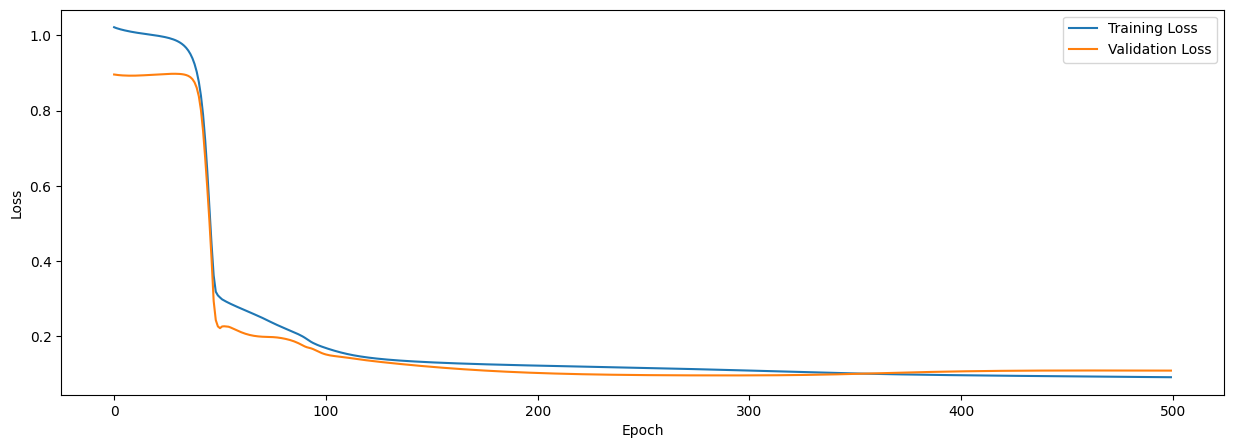

In [26]:
lstmATTN = LSTMAttn(1, 100, horizon, 1).to(device)

lr = 0.0001
optimizer = optim.Adam(lstmATTN.parameters(), lr=lr)


train_loss, val_loss = train_model(
    lstmATTN,
    train_loader_rnn,
    val_loader_rnn,
    criterion,
    optimizer,
    device,
    epochs=500,
)

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

MSE: 430.9210671015829
R2: 0.8453550000277429


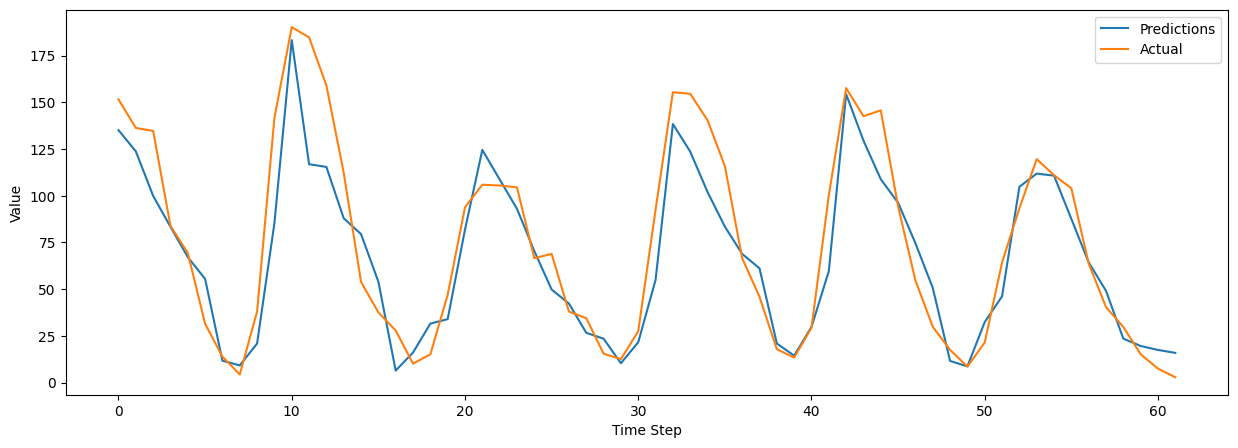

In [27]:
lstmATTN.eval()
preds = lstmATTN(torch.tensor(test_X_rnn, dtype=dtype).to(device)).cpu().detach().squeeze()

preds = preds * sigma + mu
test_y_rescaled = test_y * sigma + mu

print(f"MSE: {mean_squared_error(test_y_rescaled, preds)}")
print(f"R2: {r2_score(test_y_rescaled, preds)}")

plt.plot(preds, label="Predictions")
plt.plot(test_y_rescaled, label="Actual")

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()